# 04 - Clusterização

Com as features definidas no notebook 03, chegou a hora de agrupar os 167 países. Duas perguntas precisam de resposta: quantos grupos fazem sentido, e o resultado é robusto (ou muda muito se eu trocar de algoritmo)?

## Importando as bibliotecas

In [1]:
import sys
sys.path.append('..')

import json
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import dataframe_padronizado
from src.clustering import avaliar_faixa_de_k, rodar_kmeans, rodar_hierarquico, comparar_clusterizacoes
from src.visualization import configurar_estilo, plot_cotovelo_silhouette

configurar_estilo()

## Carregando os dados

In [2]:
df = pd.read_csv('../data/raw/dataset_paises.csv')

with open('../data/processed/features_selecionadas.json') as f:
    features = json.load(f)

print("Features usadas no cluster:", features)

X_escalado, scaler = dataframe_padronizado(df, features)
X_escalado = X_escalado[features].values

Features usadas no cluster: ['mortalidade_infantil', 'exportacoes', 'saude', 'importacoes', 'inflacao', 'expectativa_vida', 'fertilidade_total', 'pib_per_capita']


## Quantos clusters?

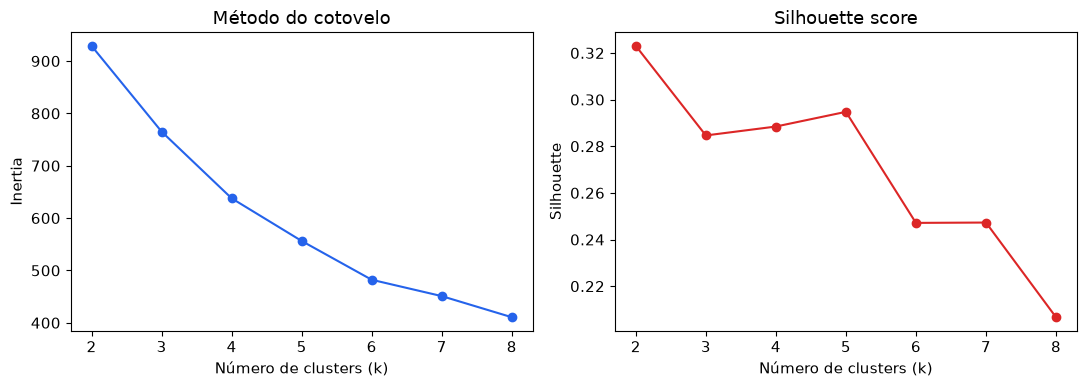

,k,inertia,silhouette
0,2,928.930,0.323
1,3,765.193,0.285
2,4,637.778,0.288
3,5,556.297,0.295
4,6,482.176,0.247
5,7,450.951,0.247
6,8,410.628,0.207


In [3]:
#Metodo do cotovelo e silhouette para determinar o número ideal de clusters
metricas = avaliar_faixa_de_k(X_escalado, k_range=range(2, 9))
plot_cotovelo_silhouette(metricas)
plt.show()
metricas.round(3)

* k=2 teve o maior valor, mas a diferença para k=3 a k=5 é pequena.
* k=3 foi escolhido pela maior interpretabilidade para o case.
* Grupos: desenvolvidos, em desenvolvimento e menos desenvolvidos.
* k maiores: apenas isolam alguns países muito ricos, sem mudar a conclusão sobre quem mais precisa de ajuda.

## Rodando o K-Means final (k=3)

In [4]:
kmeans_final, labels_kmeans = rodar_kmeans(X_escalado, k=3)
df['cluster'] = labels_kmeans
df['cluster'].value_counts().sort_index().rename('nº de países')

cluster
0    89
1    31
2    47
Name: nº de países, dtype: int64

## Validando com um segundo método
Validando com clusterização hierárquica e comparando as duas partições com o Adjusted Rand Index (ARI),quanto mais perto de 1, mais as duas concordam.

In [5]:
labels_hc = rodar_hierarquico(X_escalado, k=3)
df['cluster_hc'] = labels_hc

ari = comparar_clusterizacoes(df['cluster'], df['cluster_hc'])
print(f"Concordância entre K-Means e clusterização hierárquica (ARI): {ari:.3f}")

pd.crosstab(df['cluster'], df['cluster_hc'], rownames=['K-Means'], colnames=['Hierárquico'])

Concordância entre K-Means e clusterização hierárquica (ARI): 0.784


Hierárquico,0,1,2
K-Means,,,
0,0,5,84
1,25,0,6
2,0,46,1


A concordância é razoável, os extremos aparecem quase iguais nos dois métodos, indicando que os grupos são consistentes e não dependem de um único algoritmo.

## Salvando o resultado

In [6]:
df.to_csv('../data/processed/paises_clusterizados.csv', index=False)
print("Salvo em data/processed/paises_clusterizados.csv")

Salvo em data/processed/paises_clusterizados.csv
